In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import preprocess_input

In [2]:
train_data= ("../data/chest_xray/train")
test_data=("../data/chest_xray/test")
val_data=("../data/chest_xray/val")

In [3]:
train_datagen= ImageDataGenerator(
    preprocessing_function= preprocess_input, 
    
    rotation_range= 20, 
    zoom_range=0.2, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    horizontal_flip=True
    )

test_datagen= ImageDataGenerator(
    preprocessing_function= preprocess_input
)

In [4]:
train_image= train_datagen.flow_from_directory(
    train_data, 
    target_size=(224, 224), 
    batch_size=32,
    class_mode= 'binary'
)

test_image= test_datagen.flow_from_directory(
    test_data, 
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle = False
)

val_image= test_datagen.flow_from_directory(
    val_data,
    target_size=(224, 224),
    batch_size=32, 
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [5]:
print(train_image.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6216307].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6332066].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5345767].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117257..2.639351].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6291625].


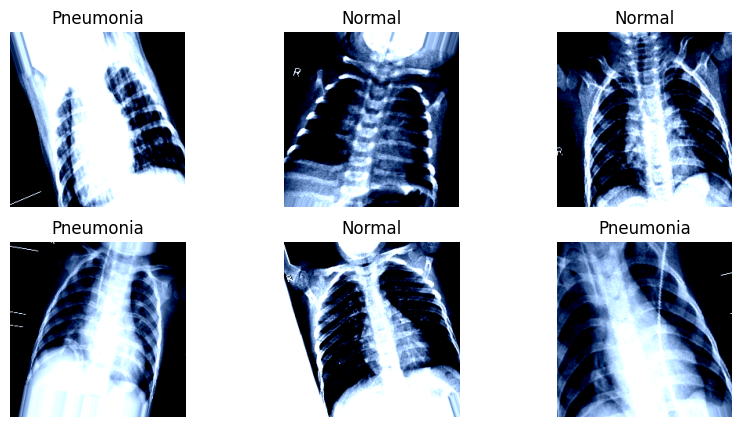

In [6]:
images, labels= next(train_image)

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] ==1 else "Normal")
    plt.axis("off")
    
plt.show()

In [7]:
base_model=DenseNet121(
    weights='imagenet',
    include_top= False,
    input_shape=(224,224,3)
)

In [26]:
for layer in base_model.layers[-20:]:
    layer.trainable=True
    
for layer in base_model.layers[-25:]:
    print(layer.name, layer.trainable)

conv5_block13_2_conv False
conv5_block13_concat False
conv5_block14_0_bn False
conv5_block14_0_relu False
conv5_block14_1_conv False
conv5_block14_1_bn True
conv5_block14_1_relu True
conv5_block14_2_conv True
conv5_block14_concat True
conv5_block15_0_bn True
conv5_block15_0_relu True
conv5_block15_1_conv True
conv5_block15_1_bn True
conv5_block15_1_relu True
conv5_block15_2_conv True
conv5_block15_concat True
conv5_block16_0_bn True
conv5_block16_0_relu True
conv5_block16_1_conv True
conv5_block16_1_bn True
conv5_block16_1_relu True
conv5_block16_2_conv True
conv5_block16_concat True
bn True
relu True


In [27]:
from tensorflow.keras.layers import (
    Dense,
    Dropout
    )

In [28]:
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128, activation='relu')(x)
x= Dropout(0.5)(x)

predictions=Dense(1, activation ='sigmoid')(x)

In [29]:
model=Model(
    inputs=base_model.input, 
    outputs=predictions
)

In [30]:
from tensorflow.keras.optimizers import Adam

In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
early_stop= EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
    )

In [34]:
history=model.fit(
    train_image, 
    validation_data= val_image,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 669ms/step - accuracy: 0.5583 - loss: 0.8254 - val_accuracy: 0.8125 - val_loss: 0.5254
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 669ms/step - accuracy: 0.7477 - loss: 0.5075 - val_accuracy: 1.0000 - val_loss: 0.4270
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.8112 - loss: 0.4076 - val_accuracy: 1.0000 - val_loss: 0.3604
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 716ms/step - accuracy: 0.8409 - loss: 0.3463 - val_accuracy: 1.0000 - val_loss: 0.3148
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.8779 - loss: 0.2897 - val_accuracy: 1.0000 - val_loss: 0.2771


In [35]:
test_loss, test_accuracy= model.evaluate(test_image)
print("Test Loss", test_loss)
print('Test Accuracy', test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 603ms/step - accuracy: 0.8237 - loss: 0.3611
Test Loss 0.3610769212245941
Test Accuracy 0.8237179517745972


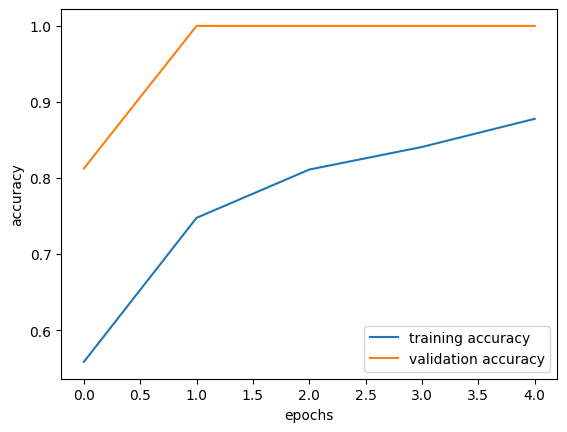

In [36]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

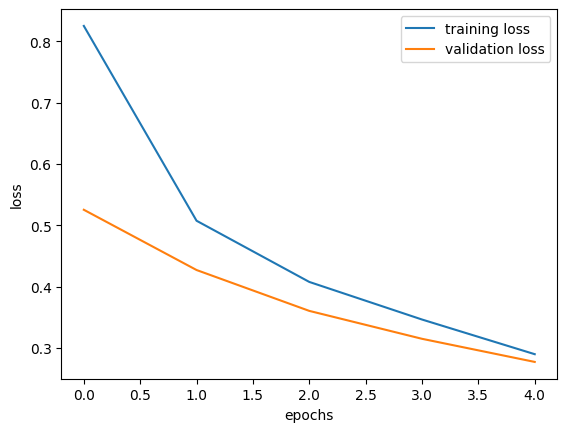

In [37]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label= 'validation loss')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [38]:
test_image.reset()

In [39]:
predictons_image=model.predict(test_image)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 648ms/step


In [40]:
predicted_classes=(predictons_image > 0.5).astype('int32')

In [41]:
true_classes=test_image.classes

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

In [43]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.87      0.62      0.72       234
           1       0.81      0.95      0.87       390

    accuracy                           0.82       624
   macro avg       0.84      0.78      0.80       624
weighted avg       0.83      0.82      0.82       624



In [44]:
model.save("../model/densenet_lastlayers.h5")